<a href="https://colab.research.google.com/github/rubyat43/220143_SVM_-_KNN/blob/main/220143_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ***Library Functions.***

In [88]:
url = 'https://raw.githubusercontent.com/rubyat43/220143_SVM_-_KNN/refs/heads/main/becandata.csv'

df = pd.read_csv(url)

print("Dataset loaded successfully from GitHub!")
print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Dataset loaded successfully from GitHub!
Shape: 569 rows and 33 columns


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# ***Dataset directly loaded from GitHub.***

In [89]:
print(" Dataset Shape:", df.shape)
print(f"\n We have {df.shape[0]} patients and {df.shape[1]} columns\n")

print(" Column Names:")
for i, col in enumerate(df.columns):
    print(f"  {i+1}. {col}")

print("Dataset Info:")
print("\n")
df.info()

 Dataset Shape: (569, 33)

 We have 569 patients and 33 columns

 Column Names:
  1. id
  2. diagnosis
  3. radius_mean
  4. texture_mean
  5. perimeter_mean
  6. area_mean
  7. smoothness_mean
  8. compactness_mean
  9. concavity_mean
  10. concave points_mean
  11. symmetry_mean
  12. fractal_dimension_mean
  13. radius_se
  14. texture_se
  15. perimeter_se
  16. area_se
  17. smoothness_se
  18. compactness_se
  19. concavity_se
  20. concave points_se
  21. symmetry_se
  22. fractal_dimension_se
  23. radius_worst
  24. texture_worst
  25. perimeter_worst
  26. area_worst
  27. smoothness_worst
  28. compactness_worst
  29. concavity_worst
  30. concave points_worst
  31. symmetry_worst
  32. fractal_dimension_worst
  33. Unnamed: 32
Dataset Info:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id               

# ***Basic shape & column info, data types & memory info. (Data Exploration).***

In [90]:
print("Statistical Summary:")
df.describe().round(2)

Statistical Summary:


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,0.0
mean,3.037183e+07,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,NaN
std,1.250206e+08,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,NaN
min,8.670000e+03,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,NaN
25%,8.692180e+05,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,NaN
50%,9.060240e+05,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,NaN
75%,8.813129e+06,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,NaN
max,9.113205e+08,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,NaN


# ***Statistical summary. (Data Exploration)***

Target Column - Diagnosis (M = Malignant, B = Benign):
diagnosis
B    357
M    212
Name: count, dtype: int64

  Benign (B)    : 357 patients (62.7%)
  Malignant (M) : 212 patients (37.3%)


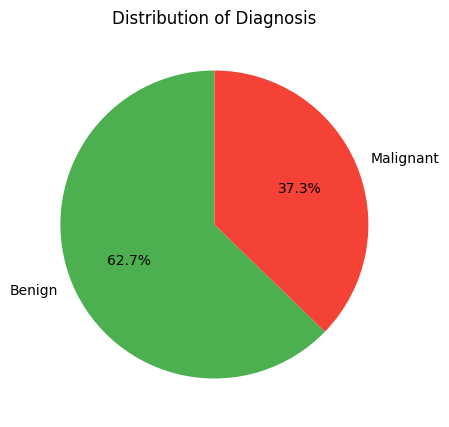

In [91]:
print("Target Column - Diagnosis (M = Malignant, B = Benign):")
print(df['diagnosis'].value_counts())
print()
print(f"  Benign (B)    : {df['diagnosis'].value_counts()['B']} patients ({df['diagnosis'].value_counts()['B']/len(df)*100:.1f}%)")
print(f"  Malignant (M) : {df['diagnosis'].value_counts()['M']} patients ({df['diagnosis'].value_counts()['M']/len(df)*100:.1f}%)")

plt.figure(figsize=(5,5))
plt.pie(df['diagnosis'].value_counts(),
        labels=['Benign', 'Malignant'],
        autopct='%1.1f%%',
        colors=['#4CAF50', '#F44336'],
        startangle=90)
plt.title('Distribution of Diagnosis')
plt.show()

# ***Check the target column & pie chart. (Data Exploration).***

Missing Values in Each Column:


             Missing Count  Missing Percentage
Unnamed: 32            569               100.0

 Total columns with missing values: 1
 Total missing cells: 569


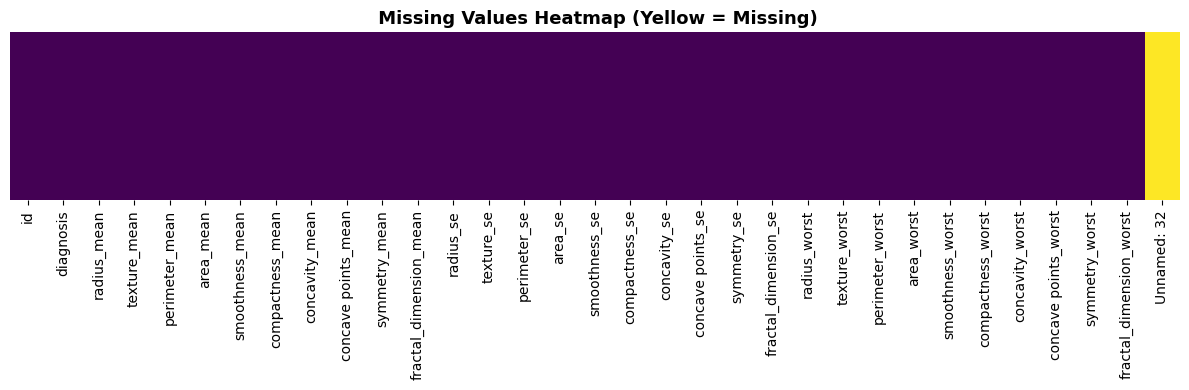

In [92]:
print("Missing Values in Each Column:")
print("\n")
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_percent.round(2)
})

missing_cols = missing_df[missing_df['Missing Count'] > 0]

if len(missing_cols) == 0:
    print("\n No missing values found in any column!")
else:
    print(missing_cols)

print(f"\n Total columns with missing values: {len(missing_cols)}")
print(f" Total missing cells: {df.isnull().sum().sum()}")

plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis',
            yticklabels=False)
plt.title(' Missing Values Heatmap (Yellow = Missing)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ***Find missing values. (Data Exploration).***

In [93]:
print("Checking for useless columns:")
print("\n")

all_null_cols = df.columns[df.isnull().all()].tolist()
print(f"\n  Completely empty columns : {all_null_cols}")
print(f"  'id' column present      : {'id' in df.columns}")

cols_to_drop = ['id'] + all_null_cols
df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"\n Dropped columns: {cols_to_drop}")
print(f" New Shape: {df.shape[0]} rows and {df.shape[1]} columns")
print(f"\n Remaining Columns:")
for i, col in enumerate(df.columns):
    print(f"  {i+1}. {col}")

Checking for useless columns:



  Completely empty columns : ['Unnamed: 32']
  'id' column present      : True

 Dropped columns: ['id', 'Unnamed: 32']
 New Shape: 569 rows and 31 columns

 Remaining Columns:
  1. diagnosis
  2. radius_mean
  3. texture_mean
  4. perimeter_mean
  5. area_mean
  6. smoothness_mean
  7. compactness_mean
  8. concavity_mean
  9. concave points_mean
  10. symmetry_mean
  11. fractal_dimension_mean
  12. radius_se
  13. texture_se
  14. perimeter_se
  15. area_se
  16. smoothness_se
  17. compactness_se
  18. concavity_se
  19. concave points_se
  20. symmetry_se
  21. fractal_dimension_se
  22. radius_worst
  23. texture_worst
  24. perimeter_worst
  25. area_worst
  26. smoothness_worst
  27. compactness_worst
  28. concavity_worst
  29. concave points_worst
  30. symmetry_worst
  31. fractal_dimension_worst


# ***Drop useless columns. (Data Exploration).***

Plotting distribution of 30 features...


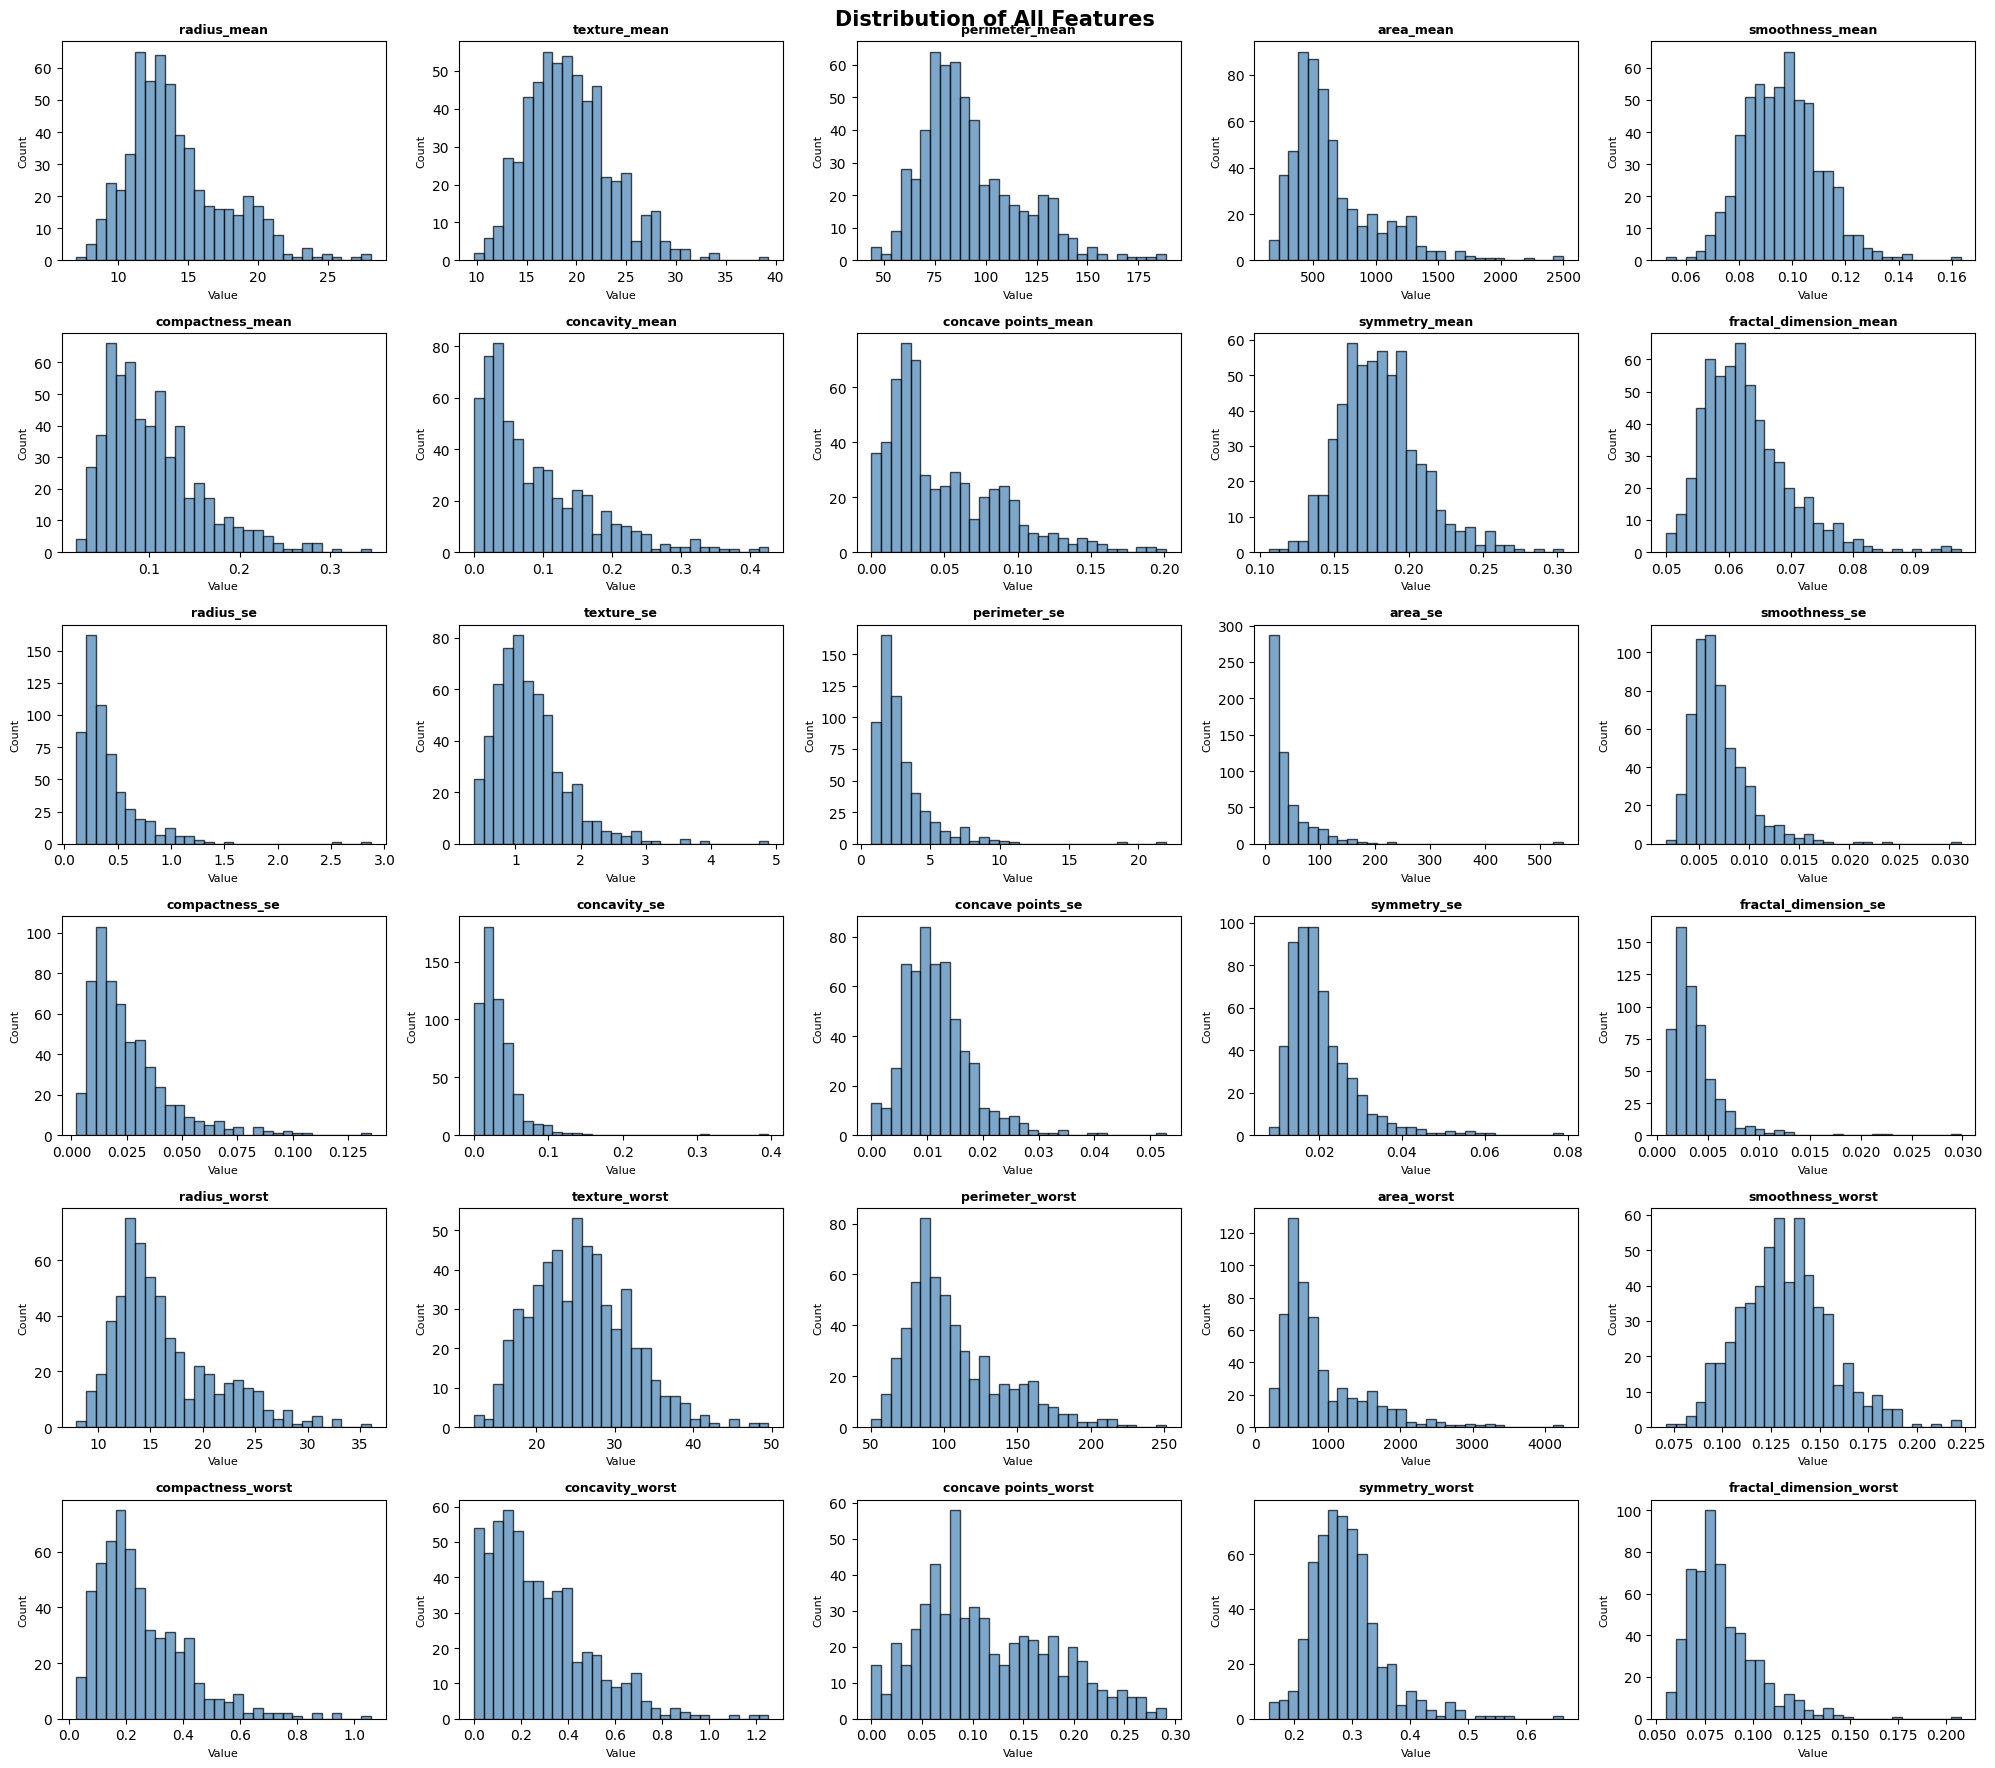

In [94]:
features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

print(f"Plotting distribution of {len(features)} features...")

fig, axes = plt.subplots(6, 5, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='steelblue',
                 edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col}', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=8)
    axes[i].set_ylabel('Count', fontsize=8)

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All Features',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ***Distribution of every feature. (Data Exploration)***

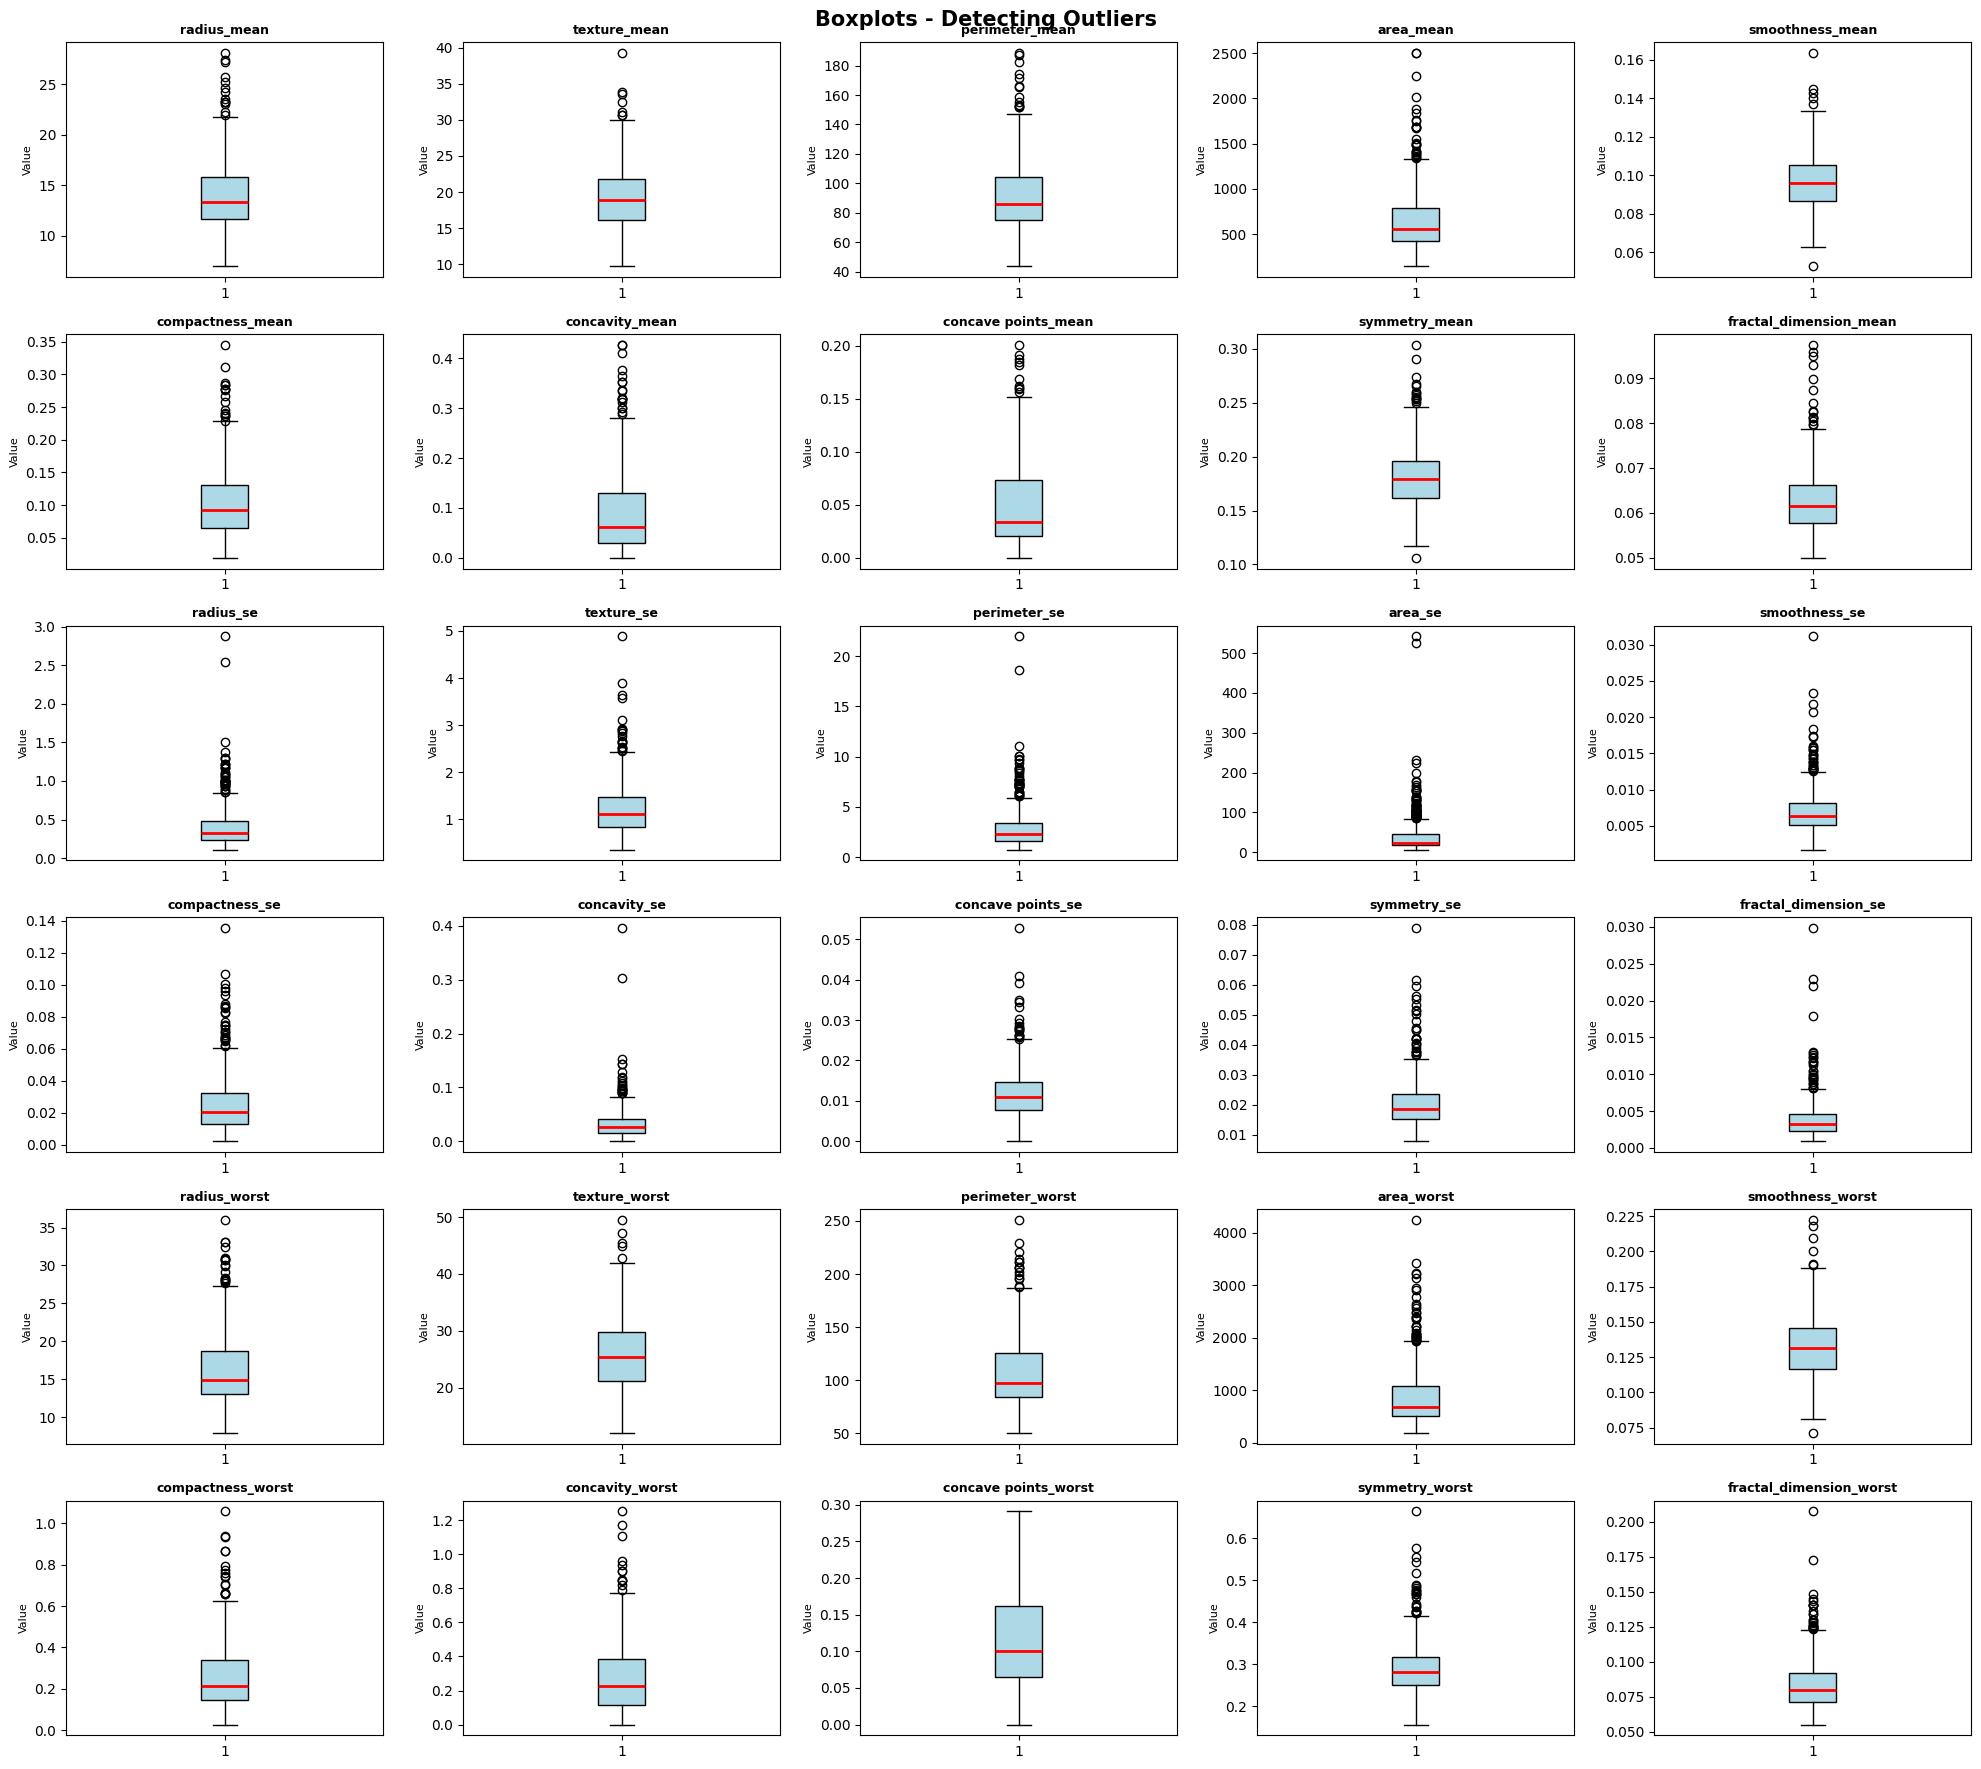

In [95]:
fig, axes = plt.subplots(6, 5, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col}', fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Value', fontsize=8)

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Detecting Outliers',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ***Boxplots — Spot Outliers. (Data Exploration)***

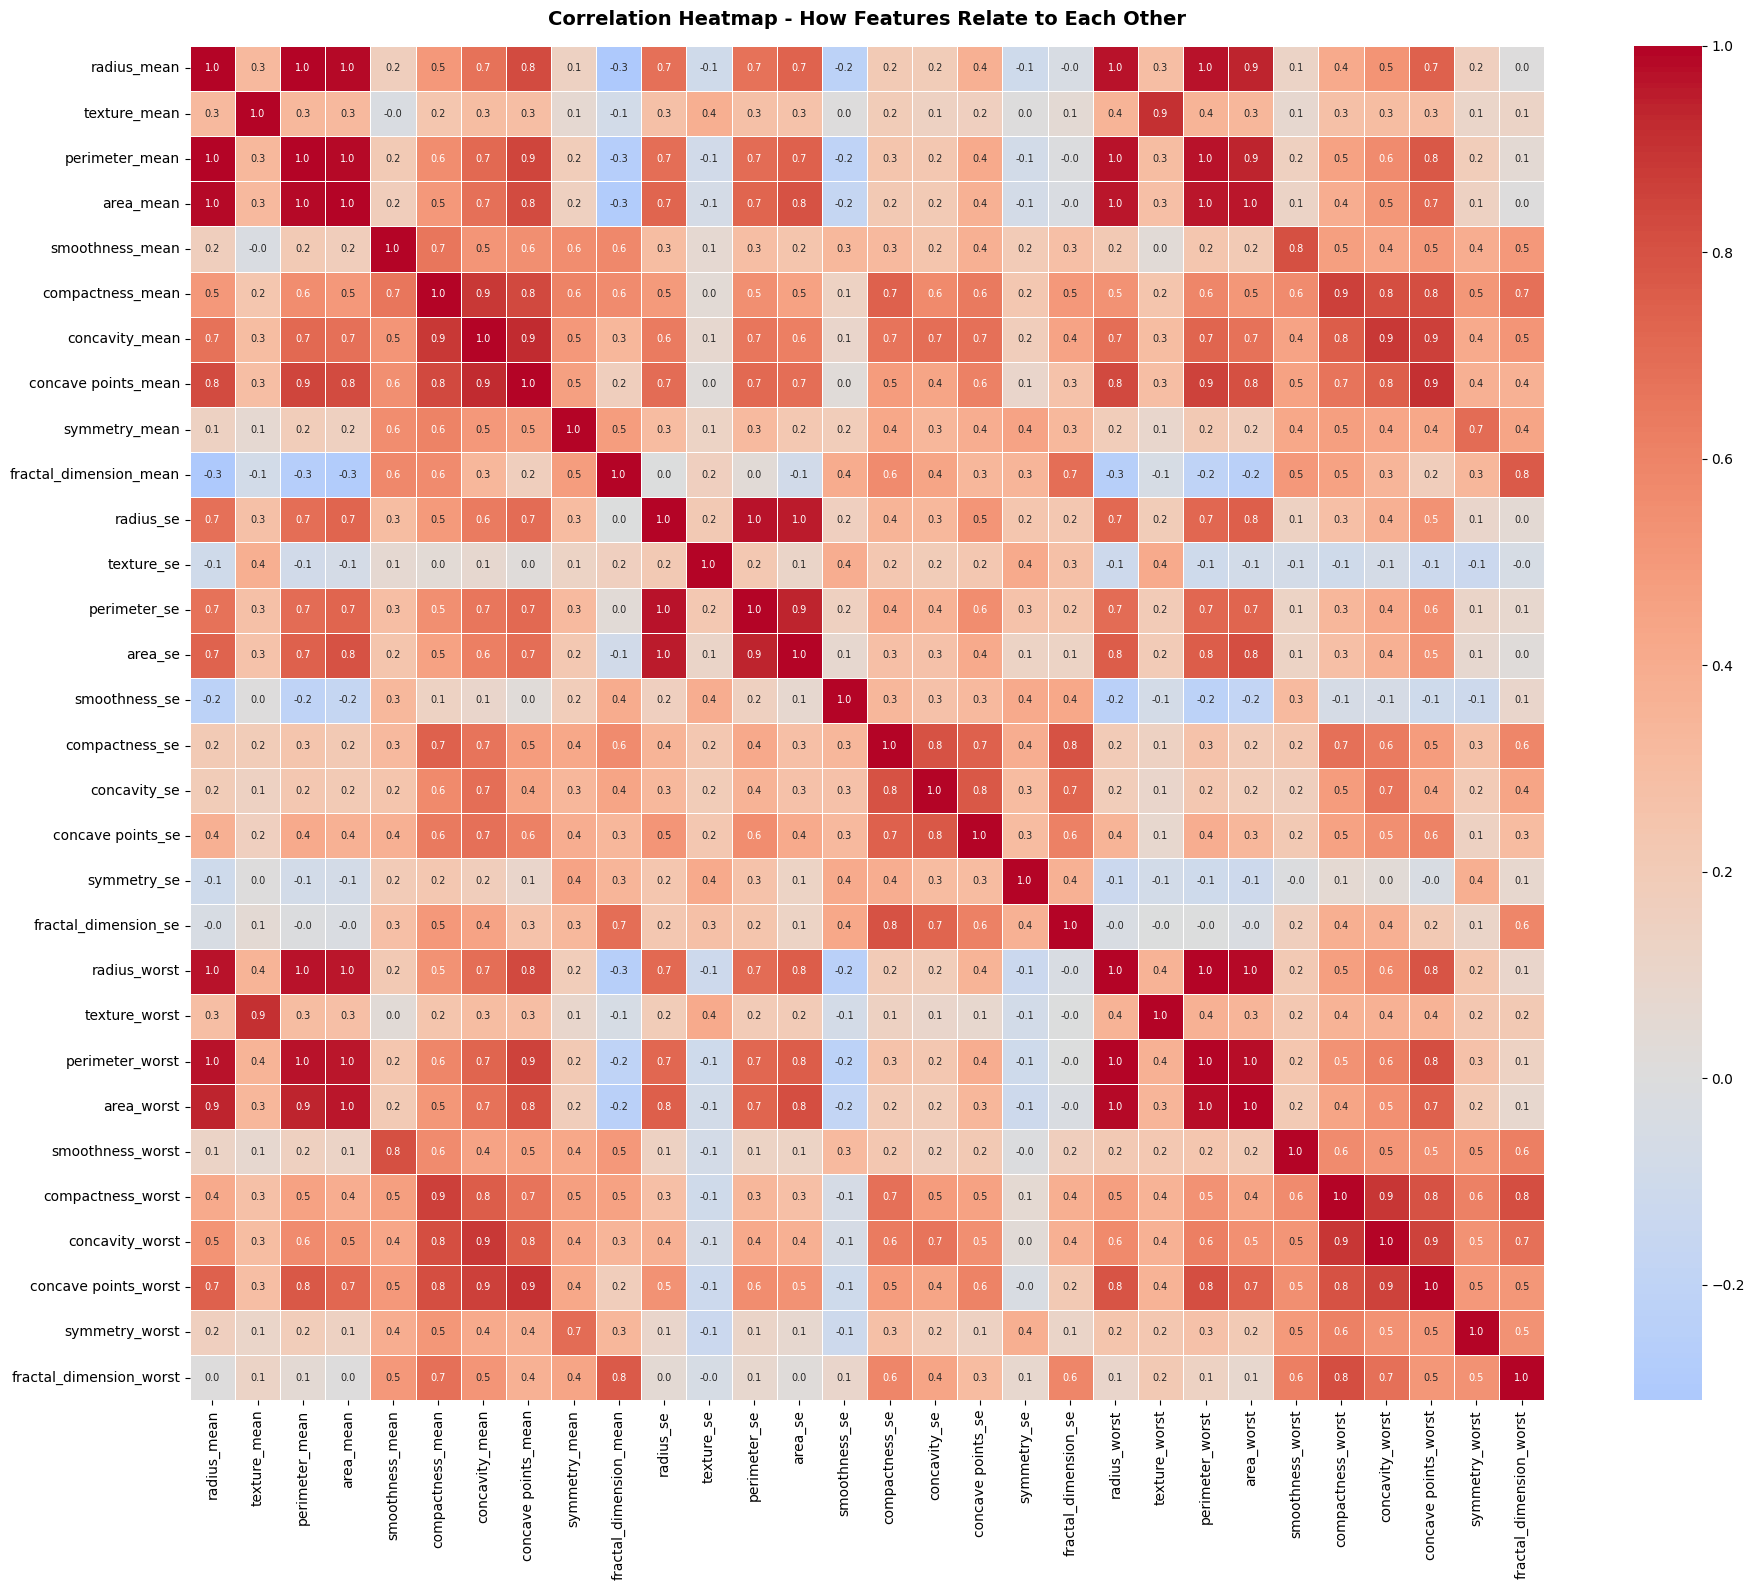

In [96]:
plt.figure(figsize=(20, 16))
correlation = df[features].corr()

sns.heatmap(correlation,
            annot=True,
            fmt='.1f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 7})

plt.title('Correlation Heatmap - How Features Relate to Each Other',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ***Correlation Heatmap. (Data Exploration)***

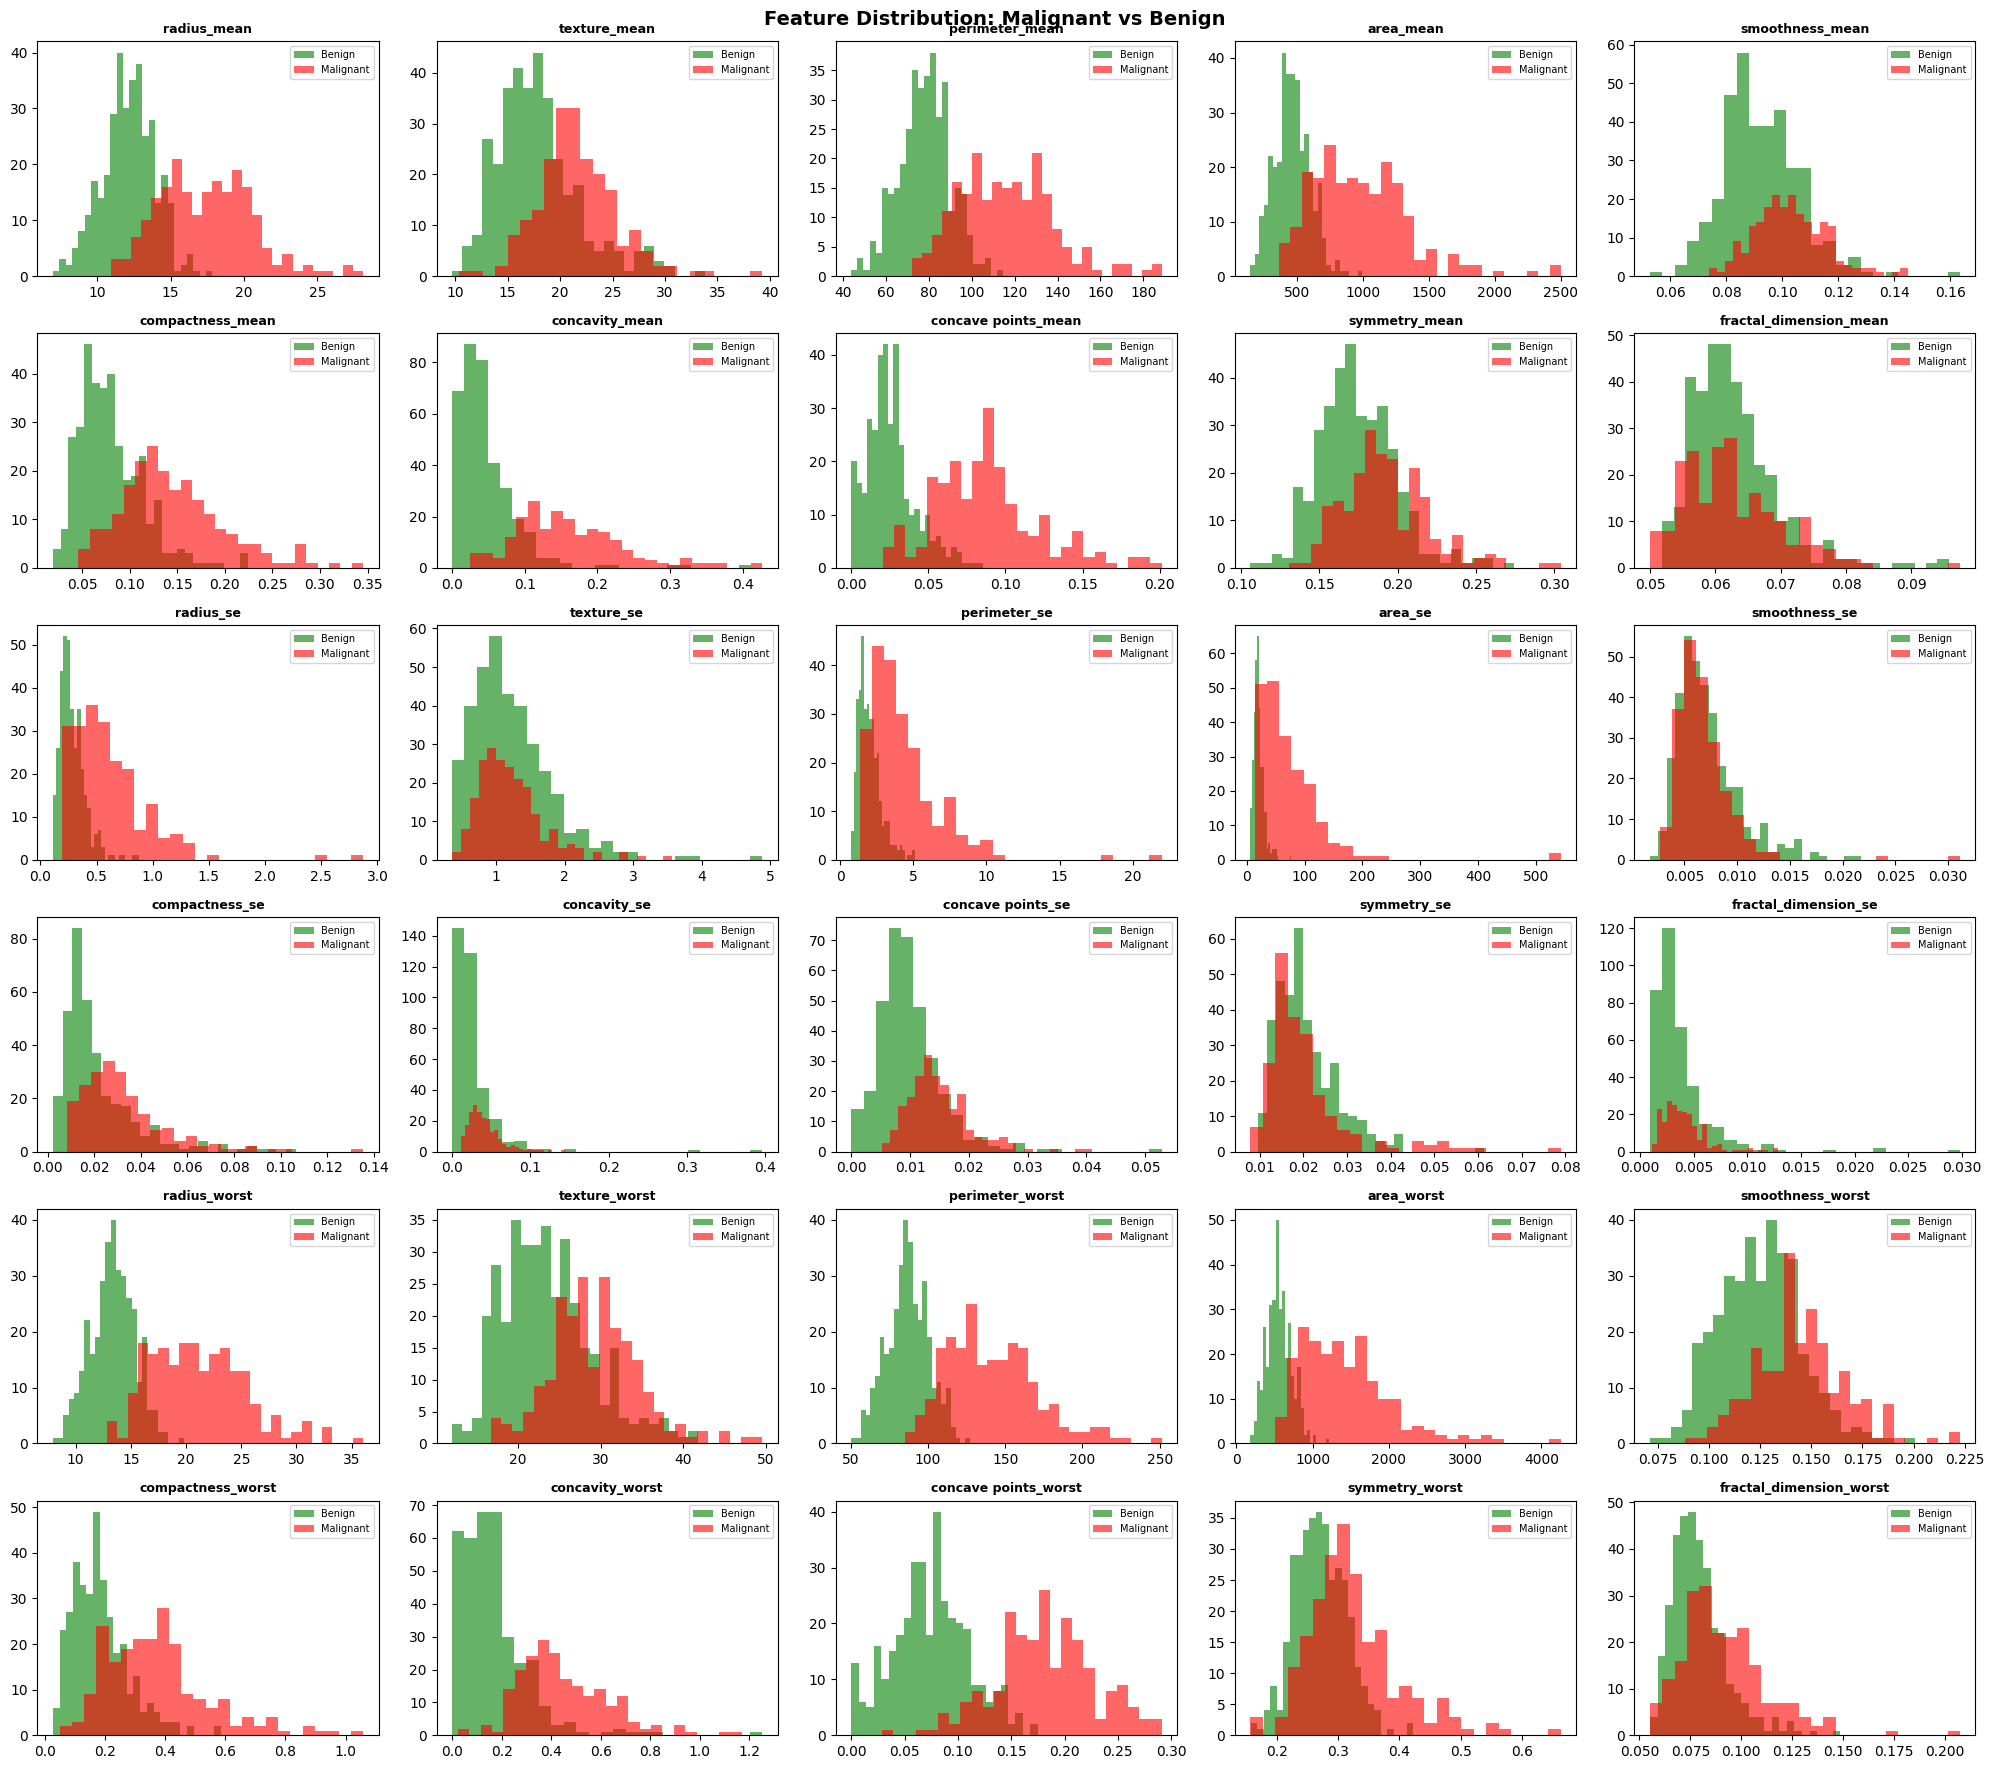

In [97]:
fig, axes = plt.subplots(6, 5, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(features):
    benign    = df[df['diagnosis'] == 'B'][col]
    malignant = df[df['diagnosis'] == 'M'][col]

    axes[i].hist(benign, bins=25, alpha=0.6,
                 color='green', label='Benign')
    axes[i].hist(malignant, bins=25, alpha=0.6,
                 color='red', label='Malignant')
    axes[i].set_title(f'{col}', fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distribution: Malignant vs Benign',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ***Feature vs diagnosis comparison.***

In [98]:
from sklearn.preprocessing import LabelEncoder

print("Target Column Before Encoding:")
print(df['diagnosis'].value_counts())
print(f"\n  Unique values: {df['diagnosis'].unique()}")

le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

print("\nTarget Column After Encoding:")
print(df['diagnosis'].value_counts())
print(f"\n  Encoding applied:")
print(f"  B (Benign)    → 0")
print(f"  M (Malignant) → 1")

Target Column Before Encoding:
diagnosis
B    357
M    212
Name: count, dtype: int64

  Unique values: ['M' 'B']

Target Column After Encoding:
diagnosis
0    357
1    212
Name: count, dtype: int64

  Encoding applied:
  B (Benign)    → 0
  M (Malignant) → 1


# ***Encode the target column.***

In [99]:
print("Checking for Categorical Columns:")
print("\n")

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

print(f"\n  Categorical columns found : {len(categorical_cols)}")
print(f"  Numerical columns found   : {len(numerical_cols)}")

if len(categorical_cols) == 0:
    print("\nNo more categorical columns found!")
    print("   All remaining features are numerical.")
    print("   diagnosis column was already encoded in previous step.")
else:
    print(f"\n  Remaining categorical columns: {categorical_cols}")
    print("\n  Applying One Hot Encoding...")
    df = pd.get_dummies(df, columns=categorical_cols)
    print("One Hot Encoding applied successfully!")

print(f"\nDataset Shape After Encoding: {df.shape}")

Checking for Categorical Columns:



  Categorical columns found : 0
  Numerical columns found   : 31

No more categorical columns found!
   All remaining features are numerical.
   diagnosis column was already encoded in previous step.

Dataset Shape After Encoding: (569, 31)


# ***Check and handle categorical features.***

In [100]:
from sklearn.preprocessing import StandardScaler

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features standardized successfully!")
print("\n")
print(f"\n  Total features scaled: {X.shape[1]}")
print(f"\n  Before scaling:")
print(f"  radius_mean  — mean: {df['radius_mean'].mean():.2f}, std: {df['radius_mean'].std():.2f}")
print(f"  area_mean    — mean: {df['area_mean'].mean():.2f}, std: {df['area_mean'].std():.2f}")

print(f"\n  After scaling:")
print(f"  radius_mean  — mean: {X_scaled[:, 0].mean():.2f}, std: {X_scaled[:, 0].std():.2f}")
print(f"  area_mean    — mean: {X_scaled[:, 2].mean():.2f}, std: {X_scaled[:, 2].std():.2f}")

Features standardized successfully!



  Total features scaled: 30

  Before scaling:
  radius_mean  — mean: 14.13, std: 3.52
  area_mean    — mean: 654.89, std: 351.91

  After scaling:
  radius_mean  — mean: -0.00, std: 1.00
  area_mean    — mean: -0.00, std: 1.00


# ***Standardize the features.***

In [101]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=42)

print("Data split successfully!")
print("\n")
print(f"  Total dataset    : {len(X_scaled)} samples")
print(f"  Training set     : {len(X_train)} samples ({len(X_train)/len(X_scaled)*100:.1f}%)")
print(f"  Validation set   : {len(X_val)} samples ({len(X_val)/len(X_scaled)*100:.1f}%)")
print(f"  Test set         : {len(X_test)} samples ({len(X_test)/len(X_scaled)*100:.1f}%)")

print(f"\n  Training set diagnosis split:")
print(f"  Benign    : {(y_train==0).sum()}")
print(f"  Malignant : {(y_train==1).sum()}")

Data split successfully!


  Total dataset    : 569 samples
  Training set     : 410 samples (72.1%)
  Validation set   : 73 samples (12.8%)
  Test set         : 86 samples (15.1%)

  Training set diagnosis split:
  Benign    : 256
  Malignant : 154


# ***Split data into train, validation & test sets.***

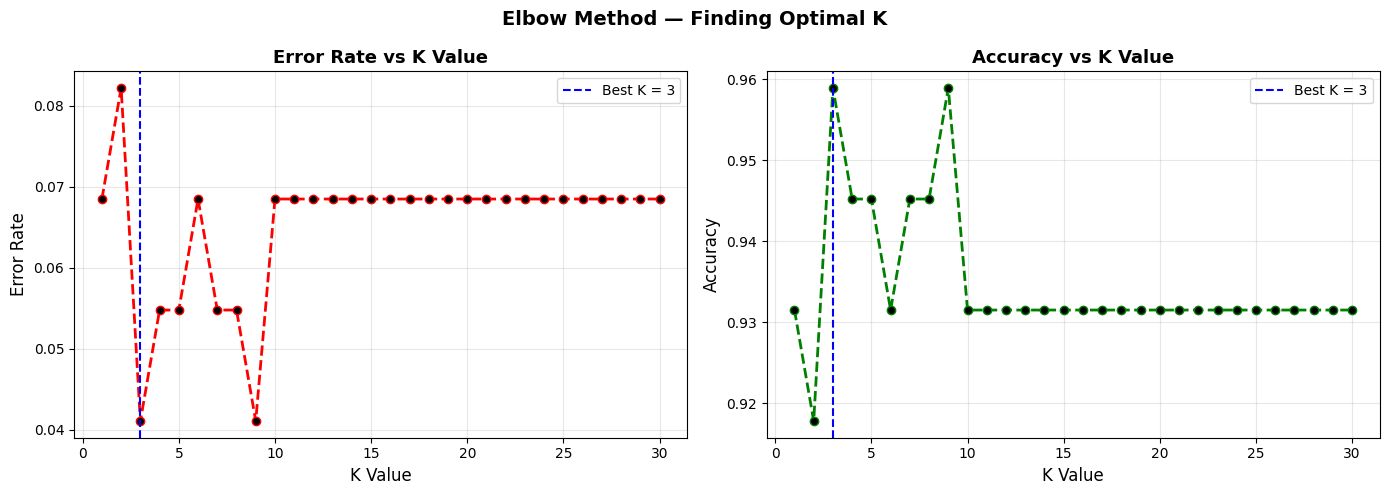


Best K value found: 3
   Accuracy at K=3: 95.89%


In [102]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 31)
error_rates = []
accuracy_rates = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_val)
    error_rates.append(1 - accuracy_score(y_val, y_pred))
    accuracy_rates.append(accuracy_score(y_val, y_pred))

best_k = k_values[error_rates.index(min(error_rates))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, error_rates, color='red',
             linestyle='--', marker='o', markerfacecolor='black',
             markersize=6, linewidth=2)
axes[0].axvline(x=best_k, color='blue', linestyle='--',
                label=f'Best K = {best_k}')
axes[0].set_title('Error Rate vs K Value',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('K Value', fontsize=12)
axes[0].set_ylabel('Error Rate', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(k_values, accuracy_rates, color='green',
             linestyle='--', marker='o', markerfacecolor='black',
             markersize=6, linewidth=2)
axes[1].axvline(x=best_k, color='blue', linestyle='--',
                label=f'Best K = {best_k}')
axes[1].set_title('Accuracy vs K Value',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('K Value', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Elbow Method — Finding Optimal K',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nBest K value found: {best_k}")
print(f"   Accuracy at K={best_k}: {accuracy_rates[best_k-1]*100:.2f}%")

# ***Elbow Method — Find the best K.***

In [103]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors' : list(range(1, 31)),
    'weights'     : ['uniform', 'distance'],
    'metric'      : ['minkowski', 'euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

print("Searching for best parameters... this may take a moment!")
grid_search.fit(X_train, y_train)

print("\nSearch complete!")
print("\n")
print(f"  Best K          : {grid_search.best_params_['n_neighbors']}")
print(f"  Best Weight     : {grid_search.best_params_['weights']}")
print(f"  Best Metric     : {grid_search.best_params_['metric']}")
print(f"  Best Accuracy   : {grid_search.best_score_*100:.2f}%")

Searching for best parameters... this may take a moment!
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Search complete!


  Best K          : 4
  Best Weight     : distance
  Best Metric     : manhattan
  Best Accuracy   : 97.80%


# ***Hyperparameter tuning with GridSearchCV.***

5-Fold Cross Validation Results:


   Fold 1: 96.34%
   Fold 2: 97.56%
   Fold 3: 97.56%
   Fold 4: 98.78%
   Fold 5: 98.78%

   Mean Accuracy  : 97.80%
   Std Deviation  : 0.91%
   Min Accuracy   : 96.34%
   Max Accuracy   : 98.78%


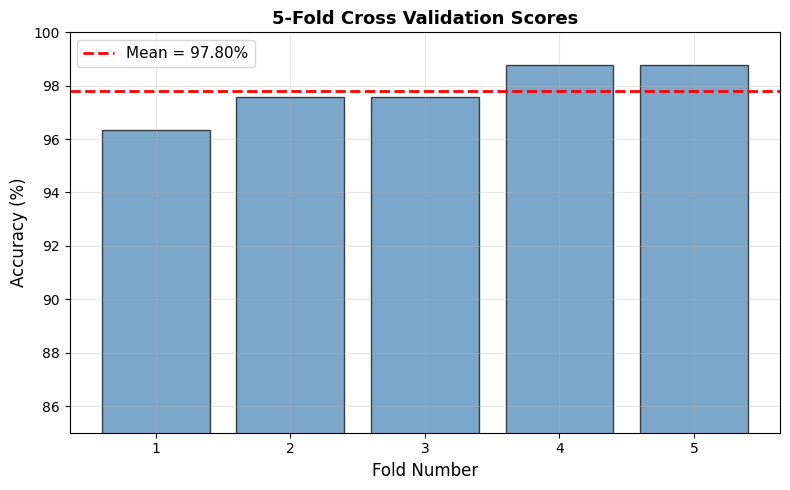

In [104]:
from sklearn.model_selection import cross_val_score

best_params = grid_search.best_params_

knn_cv = KNeighborsClassifier(
    n_neighbors = best_params['n_neighbors'],
    weights     = best_params['weights'],
    metric      = best_params['metric']
)

cv_scores = cross_val_score(knn_cv, X_train, y_train, cv=5, scoring='accuracy')

print("5-Fold Cross Validation Results:")
print("\n")
for i, score in enumerate(cv_scores):
    print(f"   Fold {i+1}: {score*100:.2f}%")

print(f"\n   Mean Accuracy  : {cv_scores.mean()*100:.2f}%")
print(f"   Std Deviation  : {cv_scores.std()*100:.2f}%")
print(f"   Min Accuracy   : {cv_scores.min()*100:.2f}%")
print(f"   Max Accuracy   : {cv_scores.max()*100:.2f}%")

plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_scores*100,
        color='steelblue', edgecolor='black', alpha=0.7)
plt.axhline(y=cv_scores.mean()*100, color='red',
            linestyle='--', linewidth=2,
            label=f'Mean = {cv_scores.mean()*100:.2f}%')
plt.title('5-Fold Cross Validation Scores',
          fontsize=13, fontweight='bold')
plt.xlabel('Fold Number', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend(fontsize=11)
plt.ylim(85, 100)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ***Cross validation results.***

In [105]:
from sklearn.neighbors import KNeighborsClassifier

best_params = grid_search.best_params_

print("Best Parameters Found:")
print("\n")
for param, value in best_params.items():
    print(f"  {param:15s}: {value}")

final_knn = KNeighborsClassifier(
    n_neighbors = best_params['n_neighbors'],
    weights     = best_params['weights'],
    metric      = best_params['metric']
)

final_knn.fit(X_train, y_train)

print("\nFinal KNN model trained with best parameters!")
print(f"   Trained on : {len(X_train)} samples")
print(f"   Features   : {X_train.shape[1]} medical measurements")

Best Parameters Found:


  metric         : manhattan
  n_neighbors    : 4
  weights        : distance

Final KNN model trained with best parameters!
   Trained on : 410 samples
   Features   : 30 medical measurements


# ***Train final KNN model with best parameters.***

Final Model Performance on Validation Set:


  Accuracy  : 95.89%
  Precision : 100.00%
  Recall    : 88.46%
  F1 Score  : 93.88%
  AUC Score : 95.99%


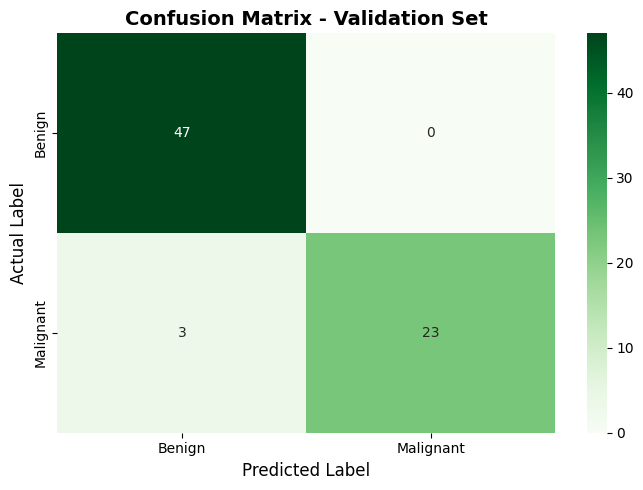

In [106]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

y_val_pred = final_knn.predict(X_val)
y_val_prob = final_knn.predict_proba(X_val)[:, 1]

val_accuracy  = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall    = recall_score(y_val, y_val_pred)
val_f1        = f1_score(y_val, y_val_pred)
val_auc       = roc_auc_score(y_val, y_val_prob)

print("Final Model Performance on Validation Set:")
print("\n")
print(f"  Accuracy  : {val_accuracy*100:.2f}%")
print(f"  Precision : {val_precision*100:.2f}%")
print(f"  Recall    : {val_recall*100:.2f}%")
print(f"  F1 Score  : {val_f1*100:.2f}%")
print(f"  AUC Score : {val_auc*100:.2f}%")

cm_val = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_val,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])

plt.title('Confusion Matrix - Validation Set',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# ***Evaluate on validation set.***

In [107]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_test_pred = final_knn.predict(X_test)
y_test_prob = final_knn.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall    = recall_score(y_test, y_test_pred)
f1        = f1_score(y_test, y_test_pred)
auc       = roc_auc_score(y_test, y_test_prob)

print("Final Model Performance on Test Set:")
print("\n")
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")
print(f"  AUC Score : {auc*100:.2f}%")

Final Model Performance on Test Set:


  Accuracy  : 96.51%
  Precision : 96.77%
  Recall    : 93.75%
  F1 Score  : 95.24%
  AUC Score : 98.12%


# ***Evaluate final model on test set.***

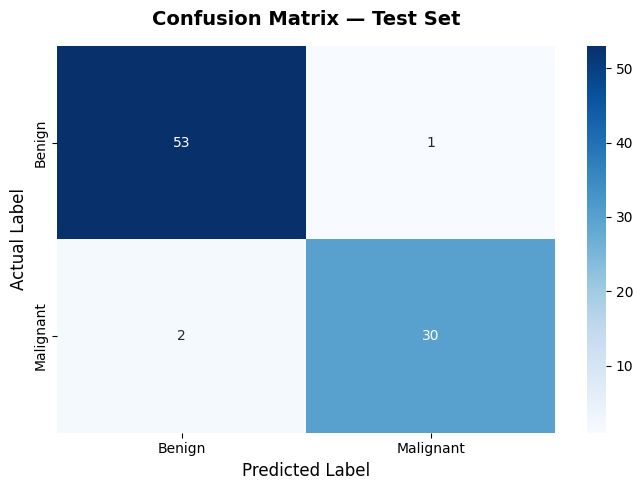



  True Negatives  (TN): 53 — Correctly predicted Benign
  False Positives (FP): 1 — Said Malignant but actually Benign
  False Negatives (FN): 2 — Said Benign but actually Malignant
  True Positives  (TP): 30 — Correctly predicted Malignant



  Total Correct   : 83 out of 86 patients
  Total Wrong     : 3 out of 86 patients


In [108]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])

plt.title('Confusion Matrix — Test Set',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print("\n")
print(f"  True Negatives  (TN): {tn} — Correctly predicted Benign")
print(f"  False Positives (FP): {fp} — Said Malignant but actually Benign")
print(f"  False Negatives (FN): {fn} — Said Benign but actually Malignant")
print(f"  True Positives  (TP): {tp} — Correctly predicted Malignant")
print("\n")
print(f"\n  Total Correct   : {tn+tp} out of {len(y_test)} patients")
print(f"  Total Wrong     : {fp+fn} out of {len(y_test)} patients")

# ***Confusion Matrix Heatmap.***

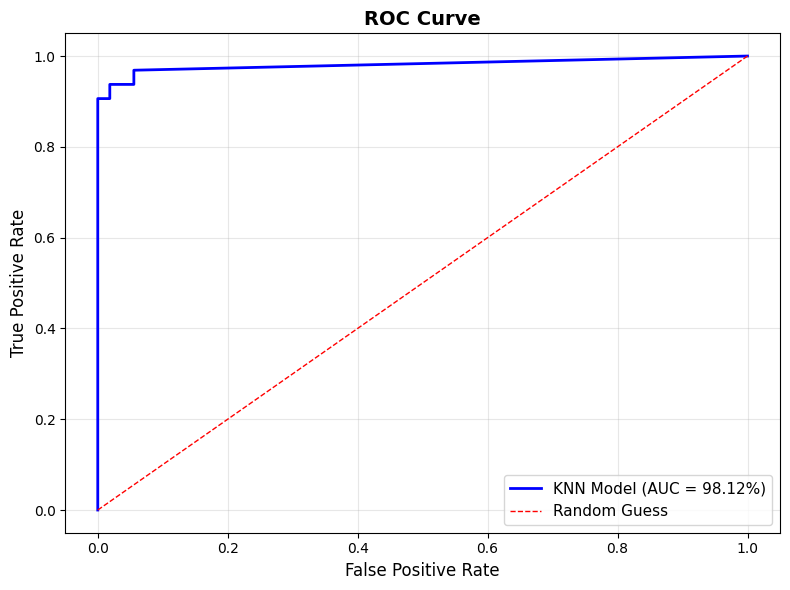

In [109]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2,
         label=f'KNN Model (AUC = {auc*100:.2f}%)')
plt.plot([0, 1], [0, 1], color='red', linewidth=1,
         linestyle='--', label='Random Guess')

plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ***ROC Curve.***

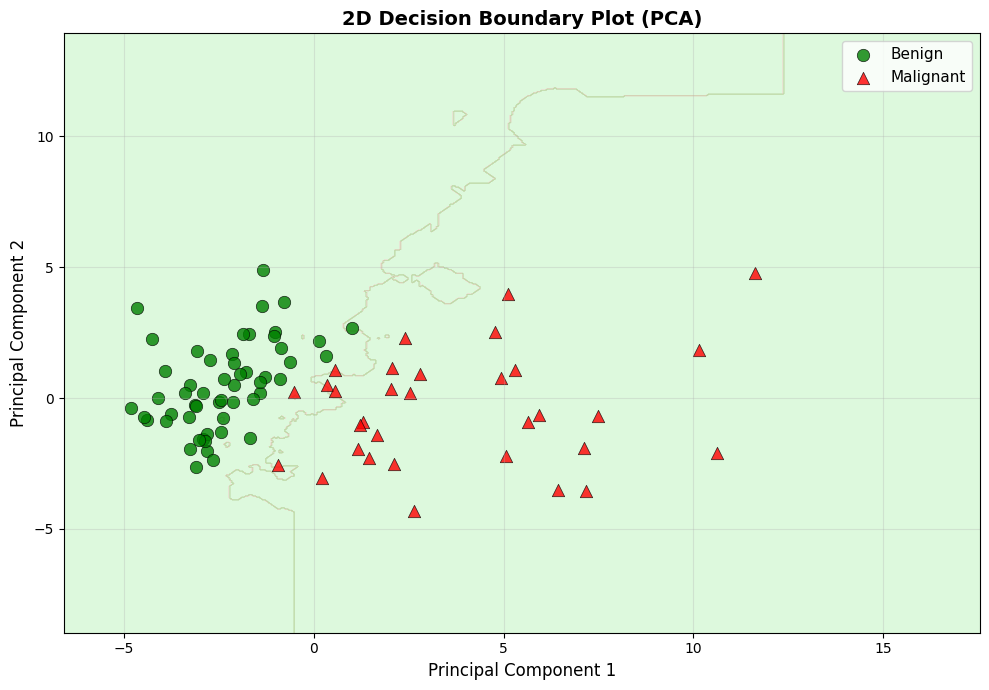

In [110]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d  = pca.transform(X_test)

knn_2d = KNeighborsClassifier(
    n_neighbors = best_params['n_neighbors'],
    weights     = best_params['weights'],
    metric      = best_params['metric']
)
knn_2d.fit(X_train_2d, y_train)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3,
             colors=['#90EE90', '#FFB6C1'])

benign    = y_test.values == 0
malignant = y_test.values == 1

plt.scatter(X_test_2d[benign, 0], X_test_2d[benign, 1],
            color='green', marker='o', s=80,
            edgecolor='black', linewidth=0.5,
            label='Benign', alpha=0.8)

plt.scatter(X_test_2d[malignant, 0], X_test_2d[malignant, 1],
            color='red', marker='^', s=80,
            edgecolor='black', linewidth=0.5,
            label='Malignant', alpha=0.8)

plt.title('2D Decision Boundary Plot (PCA)',
          fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ***2D decision boundary plot.***

In [111]:
actual    = list(y_test.values[:10])
predicted = list(y_test_pred[:10])
proba_no  = list((1 - y_test_prob[:10]).round(2))
proba_yes = list(y_test_prob[:10].round(2))

results = pd.DataFrame({
    'Actual'           : ['Malignant' if a==1 else 'Benign' for a in actual],
    'Predicted'        : ['Malignant' if p==1 else 'Benign' for p in predicted],
    'Prob - Benign'    : proba_no,
    'Prob - Malignant' : proba_yes,
    'Correct?'         : ['Yes' if a==p else 'No' for a,p in zip(actual, predicted)]
})

print("Sample Predictions vs Actual (First 10 patients):")
print("\n")
print(results.to_string(index=False))

Sample Predictions vs Actual (First 10 patients):


   Actual Predicted  Prob - Benign  Prob - Malignant Correct?
   Benign    Benign           1.00              0.00      Yes
Malignant Malignant           0.00              1.00      Yes
Malignant Malignant           0.00              1.00      Yes
   Benign    Benign           1.00              0.00      Yes
   Benign    Benign           1.00              0.00      Yes
Malignant Malignant           0.00              1.00      Yes
Malignant Malignant           0.00              1.00      Yes
Malignant Malignant           0.00              1.00      Yes
   Benign Malignant           0.27              0.73       No
   Benign    Benign           1.00              0.00      Yes


# ***Sample predictions with probability scores.***

In [112]:
print("*"*55)
print("         FINAL KNN MODEL SUMMARY REPORT")
print("*"*55)

print("\n DATASET")
print(f"   Name         : Breast Cancer Wisconsin Dataset")
print(f"   Source       : GitHub Repository")
print(f"   Total Samples: {len(df)} patients")
print(f"   Features     : {X.shape[1]} medical measurements")
print(f"   Target       : Benign (0) or Malignant (1)")

print("\n  BEST MODEL PARAMETERS")
for param, value in best_params.items():
    print(f"   {param:15s}: {value}")

print("\n EVALUATION METRICS — VALIDATION SET")
print(f"   Accuracy  : {val_accuracy*100:.2f}%")
print(f"   Precision : {val_precision*100:.2f}%")
print(f"   Recall    : {val_recall*100:.2f}%")
print(f"   F1 Score  : {val_f1*100:.2f}%")
print(f"   AUC Score : {val_auc*100:.2f}%")

print("\n EVALUATION METRICS — TEST SET")
print(f"   Accuracy  : {accuracy*100:.2f}%")
print(f"   Precision : {precision*100:.2f}%")
print(f"   Recall    : {recall*100:.2f}%")
print(f"   F1 Score  : {f1*100:.2f}%")
print(f"   AUC Score : {auc*100:.2f}%")

print("\n CONFUSION MATRIX — TEST SET")
print(f"   True Negatives  : {tn} (Correctly said Benign)")
print(f"   True Positives  : {tp} (Correctly said Malignant)")
print(f"   False Positives : {fp} (Said Malignant but was wrong)")
print(f"   False Negatives : {fn} (Missed actual Malignant cases)")

print("\n PREPROCESSING STEPS DONE")
print("   1. Dropped useless columns (id, unnamed)")
print("   2. Encoded target column (B→0, M→1)")
print("   3. Checked and handled categorical features")
print("   4. Standardized all features with StandardScaler")
print("   5. Split data into Train / Validation / Test sets")

print("\n HYPERPARAMETER TUNING")
print("   Method : GridSearchCV")
print("   Folds  : 5 Cross Validation")
print("   Tried  : n_neighbors, weights, metric combinations")

print("\n SCREENSHOTS TAKEN")
print("   1. Confusion Matrix Heatmap     — STEP 23")
print("   2. Elbow Method Plot            — STEP 18")
print("   3. Evaluation Metrics           — STEP 22")
print("   4. ROC Curve                    — STEP 24")
print("   5. 2D Decision Boundary Plot    — STEP 25")

print("*"*55)
print("         ASSIGNMENT COMPLETE!")
print("*"*55)

*******************************************************
         FINAL KNN MODEL SUMMARY REPORT
*******************************************************

 DATASET
   Name         : Breast Cancer Wisconsin Dataset
   Source       : GitHub Repository
   Total Samples: 569 patients
   Features     : 30 medical measurements
   Target       : Benign (0) or Malignant (1)

  BEST MODEL PARAMETERS
   metric         : manhattan
   n_neighbors    : 4
   weights        : distance

 EVALUATION METRICS — VALIDATION SET
   Accuracy  : 95.89%
   Precision : 100.00%
   Recall    : 88.46%
   F1 Score  : 93.88%
   AUC Score : 95.99%

 EVALUATION METRICS — TEST SET
   Accuracy  : 96.51%
   Precision : 96.77%
   Recall    : 93.75%
   F1 Score  : 95.24%
   AUC Score : 98.12%

 CONFUSION MATRIX — TEST SET
   True Negatives  : 53 (Correctly said Benign)
   True Positives  : 30 (Correctly said Malignant)
   False Positives : 1 (Said Malignant but was wrong)
   False Negatives : 2 (Missed actual Malignant cases

# ***Final summary report.***